# Task 2 — Data Preprocessing for a Regression Problem
### NYC-style Taxi Fare Dataset — Predicting `fare_amount`

This notebook follows on from Task 1 (EDA) and turns the raw taxi-trip dataset into a clean,
encoded, scaled, leakage-free dataset ready for modeling, then trains a baseline and a
tuned regression model.

**Sections:** Missing Values → Duplicates → Encoding → Scaling → Feature Extraction → Feature
Selection → Outliers → Train/Test Split → Cross-Validation → Hyperparameter Tuning → Results

## 0. Setup & Load Data

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, KFold, cross_val_score, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, FunctionTransformer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.max_columns', 40)
RANDOM_STATE = 42

df = pd.read_csv('r"C:\Users\Ahmed Elghrably\OneDrive\Desktop\final_internship_data.csv"')
print(df.shape)
df.head()

(500000, 26)


,User ID,User Name,Driver Name,Car Condition,Weather,Traffic Condition,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
0,KHVrEVlD,Kimberly Adams,Amy Butler,Very Good,windy,Congested Traffic,2009-06-15 17:26:21.0000001,4.5,2009-06-15 17:26:21,-1.288826,0.710721,-1.288779,0.710563,1,17,15,6,0,2009,20.265840,55.176046,14.342611,34.543548,27.572573,1.030764,-2.918897
1,lPxIuEri,Justin Tapia,Hannah Zimmerman,Excellent,cloudy,Flow Traffic,2010-01-05 16:52:16.0000002,16.9,2010-01-05 16:52:16,-1.291824,0.710546,-1.291182,0.711780,1,16,5,1,1,2010,44.667679,31.832358,23.130775,15.125872,8.755732,8.450134,-0.375217
2,gsVN8JLS,Elizabeth Lopez,Amanda Jackson,Bad,stormy,Congested Traffic,2011-08-18 00:35:00.00000049,5.7,2011-08-18 00:35:00,-1.291242,0.711418,-1.291391,0.711231,2,0,18,8,3,2011,43.597686,33.712082,19.865289,17.722624,9.847344,1.389525,2.599961
3,9I7kWFgd,Steven Wilson,Amy Horn,Very Good,stormy,Flow Traffic,2012-04-21 04:30:42.0000001,7.7,2012-04-21 04:30:42,-1.291319,0.710927,-1.291396,0.711363,1,4,21,4,5,2012,42.642965,32.556289,21.063132,15.738963,7.703421,2.799270,0.133905
4,8QN5ZaGN,Alexander Andrews,Cassandra Larson,Bad,stormy,Congested Traffic,2010-03-09 07:51:00.000000135,5.3,2010-03-09 07:51:00,-1.290987,0.711536,-1.290787,0.711811,1,7,9,3,1,2010,43.329953,39.406828,15.219339,23.732406,15.600745,1.999157,-0.502703


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 26 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   User ID            500000 non-null  str    
 1   User Name          500000 non-null  str    
 2   Driver Name        500000 non-null  str    
 3   Car Condition      500000 non-null  str    
 4   Weather            500000 non-null  str    
 5   Traffic Condition  500000 non-null  str    
 6   key                500000 non-null  str    
 7   fare_amount        500000 non-null  float64
 8   pickup_datetime    500000 non-null  str    
 9   pickup_longitude   500000 non-null  float64
 10  pickup_latitude    500000 non-null  float64
 11  dropoff_longitude  499995 non-null  float64
 12  dropoff_latitude   499995 non-null  float64
 13  passenger_count    500000 non-null  int64  
 14  hour               500000 non-null  int64  
 15  day                500000 non-null  int64  
 16  month        

## 1. Handling Missing Values

**Quantify missingness first.**

In [ ]:
missing_pct = df.isnull().mean().sort_values(ascending=False) * 100
missing_pct[missing_pct > 0]

dropoff_latitude     0.001
bearing              0.001
jfk_dist             0.001
ewr_dist             0.001
lga_dist             0.001
sol_dist             0.001
distance             0.001
nyc_dist             0.001
dropoff_longitude    0.001
dtype: float64

**Justification:** Only `dropoff_longitude`, `dropoff_latitude`, `jfk_dist`, `ewr_dist`,
`lga_dist`, `sol_dist`, `nyc_dist`, `distance` and `bearing` have any missing values, and
each is missing in only **0.001%** of rows (5 rows out of 500,000). All five geo-distance
columns and `bearing`/`distance` are missing together for the same handful of rows (they are
all derived from the same dropoff coordinates), which points to **MCAR** (a handful of
corrupted GPS readings, unrelated to any other feature or to the target). Given the
negligible size and MCAR pattern, the simplest and safest approach — **dropping these rows**
— is preferred over imputation; imputing coordinates/distances for a taxi trip risks
inventing a fictitious pickup/dropoff location, and losing 5 rows out of 500k has no
material effect on model training.

In [ ]:
df = df.dropna().reset_index(drop=True)
print('Shape after dropping the 5 MCAR rows:', df.shape)
df.isnull().sum().sum()

Shape after dropping the 5 MCAR rows: (499995, 26)


np.int64(0)

## 2. Detecting and Removing Duplicates

In [ ]:
print('Fully duplicated rows:', df.duplicated().sum())
print('Duplicated trip keys (`key`):', df['key'].duplicated().sum())
print('Duplicated `User ID`:', df['User ID'].duplicated().sum())

Fully duplicated rows: 0
Duplicated trip keys (`key`): 0


Duplicated `User ID`: 0


**Justification:** `key` is a per-trip timestamp-based identifier and `User ID` is a
per-user identifier; neither has any repeats, and there are zero fully-duplicated rows. This
dataset has no exact or key-based duplicates to remove, so no rows are dropped in this step.
We will still re-check for duplicates after encoding (see Section 3), since one-hot encoding
can coincidentally make two originally different rows identical.

## 3. Encoding Categorical Variables

First, inspect the categorical columns and their cardinality.

In [ ]:
cat_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()
for c in cat_cols:
    print(f"{c}: {df[c].nunique()} unique values")

User ID: 499995 unique values


User Name: 221673 unique values
Driver Name: 221700 unique values


Car Condition: 4 unique values
Weather: 5 unique values
Traffic Condition: 3 unique values


key: 499995 unique values


pickup_datetime: 461201 unique values


**Justification for each categorical column:**

| Column | Cardinality | Decision | Why |
|---|---|---|---|
| `User ID`, `key` | 500,000 (unique per row) | **Drop** | Pure row identifiers, one value per row — zero generalizable signal, would only enable leakage/overfitting. |
| `User Name`, `Driver Name` | ~221,700 (near-unique) | **Drop** | Essentially free-text names; extremely high cardinality with almost no repeated categories to learn a stable mean/frequency from. Not usable as a nominal or target-encoded feature at this cardinality without severe overfitting. |
| `pickup_datetime` | 461,206 (near-unique text) | **Drop (redundant)** | The dataset already provides `hour`, `day`, `month`, `weekday`, `year` decomposed from this timestamp — keeping the raw string adds nothing but cardinality. |
| `Car Condition` | 4 (`Bad` < `Good` < `Very Good` < `Excellent`) | **Ordinal Encoding** | This has a genuine order (car quality tiers), so ordinal encoding preserves that ranking instead of inventing arbitrary dummy axes. |
| `Weather` | 5 (`sunny`, `cloudy`, `rainy`, `windy`, `stormy`) | **One-Hot Encoding** | Low-cardinality, no natural order — one-hot avoids imposing a false ranking on weather types. |
| `Traffic Condition` | 3 (`Flow`, `Dense`, `Congested`) | **One-Hot Encoding** | Low-cardinality nominal category; one-hot is cheap at this cardinality and keeps interpretability for the linear baseline model. |

We also drop the raw `pickup_longitude/latitude` and `dropoff_longitude/latitude` columns:
several rows contain implausible coordinates (e.g. latitudes of 29–37, far outside any real
NYC trip), which is a data-quality issue in the raw GPS fields. The dataset already ships
engineered geo-features (`distance`, `bearing`, and distance-to-landmark columns) derived
from these coordinates, so we rely on those cleaner, already-engineered features instead of
the noisy raw coordinates.

In [ ]:
id_like_cols = ['User ID', 'key', 'User Name', 'Driver Name', 'pickup_datetime']
raw_geo_cols = ['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude']

df = df.drop(columns=id_like_cols + raw_geo_cols)
print(df.shape)
df.head()

(499995, 17)


,Car Condition,Weather,Traffic Condition,fare_amount,passenger_count,hour,day,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
0,Very Good,windy,Congested Traffic,4.5,1,17,15,6,0,2009,20.265840,55.176046,14.342611,34.543548,27.572573,1.030764,-2.918897
1,Excellent,cloudy,Flow Traffic,16.9,1,16,5,1,1,2010,44.667679,31.832358,23.130775,15.125872,8.755732,8.450134,-0.375217
2,Bad,stormy,Congested Traffic,5.7,2,0,18,8,3,2011,43.597686,33.712082,19.865289,17.722624,9.847344,1.389525,2.599961
3,Very Good,stormy,Flow Traffic,7.7,1,4,21,4,5,2012,42.642965,32.556289,21.063132,15.738963,7.703421,2.799270,0.133905
4,Bad,stormy,Congested Traffic,5.3,1,7,9,3,1,2010,43.329953,39.406828,15.219339,23.732406,15.600745,1.999157,-0.502703


In [ ]:
# Re-check for duplicates after the upcoming encoding step will be repeated later;
# for now confirm dropping ID columns didn't create duplicate rows
print('Duplicated rows after dropping ID/text columns:', df.duplicated().sum())

Duplicated rows after dropping ID/text columns: 0


## 4. Feature Extraction (before scaling/selection, informed by EDA)

* `hour`, `weekday`, and `month` are **cyclical** — hour 23 and hour 0 are one hour apart in
  reality but far apart as raw integers. We encode each with sine/cosine pairs so the model
  sees the wrap-around correctly, then drop the raw integer versions to avoid redundancy.
* We add `is_weekend` (Saturday/Sunday) since weekend demand/fare patterns often differ from
  weekdays.
* `bearing` is already an angle in radians (-π to π); we cyclically encode it the same way.
* Among the five landmark-distance columns (`jfk_dist`, `ewr_dist`, `lga_dist`, `sol_dist`,
  `nyc_dist`), a correlation check (below) shows they are **near-perfectly correlated with
  each other (r > 0.999)** — they all move together since they are all just "distance from
  the trip to a fixed point in the city," so they carry almost the same information. To
  avoid multicollinearity, we keep only `nyc_dist` (distance to the city center, the most
  general of the five) and drop the other four; this is finalized in the Feature Selection
  step.

In [ ]:
landmark_cols = ['jfk_dist', 'ewr_dist', 'lga_dist', 'sol_dist', 'nyc_dist']
print(df[landmark_cols].corr())

          jfk_dist  ewr_dist  lga_dist  sol_dist  nyc_dist
jfk_dist  1.000000  0.999994  0.999996  0.999994  0.999994
ewr_dist  0.999994  1.000000  0.999994  1.000000  1.000000
lga_dist  0.999996  0.999994  1.000000  0.999993  0.999994
sol_dist  0.999994  1.000000  0.999993  1.000000  1.000000
nyc_dist  0.999994  1.000000  0.999994  1.000000  1.000000


In [ ]:
def add_cyclical(frame):
    frame = frame.copy()
    frame['hour_sin'] = np.sin(2 * np.pi * frame['hour'] / 24)
    frame['hour_cos'] = np.cos(2 * np.pi * frame['hour'] / 24)
    frame['weekday_sin'] = np.sin(2 * np.pi * frame['weekday'] / 7)
    frame['weekday_cos'] = np.cos(2 * np.pi * frame['weekday'] / 7)
    frame['month_sin'] = np.sin(2 * np.pi * frame['month'] / 12)
    frame['month_cos'] = np.cos(2 * np.pi * frame['month'] / 12)
    frame['bearing_sin'] = np.sin(frame['bearing'])
    frame['bearing_cos'] = np.cos(frame['bearing'])
    frame['is_weekend'] = (frame['weekday'] >= 5).astype(int)
    frame = frame.drop(columns=['hour', 'weekday', 'month', 'bearing'])
    return frame

df = add_cyclical(df)
df.head()

,Car Condition,Weather,Traffic Condition,fare_amount,passenger_count,day,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,hour_sin,hour_cos,weekday_sin,weekday_cos,month_sin,month_cos,bearing_sin,bearing_cos,is_weekend
0,Very Good,windy,Congested Traffic,4.5,1,15,2009,20.265840,55.176046,14.342611,34.543548,27.572573,1.030764,-0.965926,-0.258819,0.000000,1.000000,1.224647e-16,-1.000000e+00,-0.220860,-0.975306,0
1,Excellent,cloudy,Flow Traffic,16.9,1,5,2010,44.667679,31.832358,23.130775,15.125872,8.755732,8.450134,-0.866025,-0.500000,0.781831,0.623490,5.000000e-01,8.660254e-01,-0.366475,0.930428,0
2,Bad,stormy,Congested Traffic,5.7,2,18,2011,43.597686,33.712082,19.865289,17.722624,9.847344,1.389525,0.000000,1.000000,0.433884,-0.900969,-8.660254e-01,-5.000000e-01,0.515535,-0.856869,0
3,Very Good,stormy,Flow Traffic,7.7,1,21,2012,42.642965,32.556289,21.063132,15.738963,7.703421,2.799270,0.866025,0.500000,-0.974928,-0.222521,8.660254e-01,-5.000000e-01,0.133505,0.991048,1
4,Bad,stormy,Congested Traffic,5.3,1,9,2010,43.329953,39.406828,15.219339,23.732406,15.600745,1.999157,0.965926,-0.258819,0.781831,0.623490,1.000000e+00,6.123234e-17,-0.481796,0.876283,0


## 5. Outlier Detection & Treatment

`fare_amount` (the target) and `distance`/`passenger_count` are checked for values that are
**data errors** (impossible/invalid) versus **rare-but-real** values.

In [ ]:
print('fare_amount <= 0:', (df['fare_amount'] <= 0).sum())
print('fare_amount > 200 :', (df['fare_amount'] > 200).sum())
print('passenger_count == 0:', (df['passenger_count'] == 0).sum())
print('distance == 0 (fare > 0):', ((df['distance'] == 0) & (df['fare_amount'] > 0)).sum())
print('distance > 100 miles:', (df['distance'] > 100).sum())
df[['fare_amount', 'distance', 'passenger_count']].describe()

fare_amount <= 0: 35
fare_amount > 200 : 26
passenger_count == 0: 1791
distance == 0 (fare > 0): 14247
distance > 100 miles: 1092


,fare_amount,distance,passenger_count
count,499995.000000,499995.000000,499995.000000
mean,11.358182,19.468775,1.683445
std,9.916069,367.299601,1.307391
min,-44.900000,0.000000,0.000000
25%,6.000000,1.214550,1.000000
50%,8.500000,2.116970,1.000000
75%,12.500000,3.890070,2.000000
max,500.000000,12399.956433,6.000000


In [ ]:
print(df['distance'].quantile([0.9, 0.95, 0.99, 0.995, 0.999, 1.0]))

0.900        7.042578
0.950       10.143197
0.990       20.654822
0.995       21.891510
0.999     8665.325978
1.000    12399.956433
Name: distance, dtype: float64


**Decisions (data errors → remove; rare-but-real → keep/cap):**

* **`fare_amount <= 0`** (35 rows): a taxi fare cannot be zero or negative — this is a data
  entry error, not a rare valid fare. **Dropped.**
* **`fare_amount > 200`** (26 rows, ~0.005%): fares up to ~$500 with no matching long
  distance are inconsistent with the trip data (metered NYC-style fares rarely exceed ~$100–150
  even for the longest airport runs). This is a vanishingly small, extreme tail that looks
  like corrupted entries rather than genuine expensive trips. **Dropped** (rather than
  capped) because there are only 26 such rows — too few to reliably estimate a sensible cap,
  and keeping them would let a handful of possibly-erroneous values dominate the squared-error
  loss.
* **`passenger_count == 0`** (1,796 rows, 0.36%): a trip with zero passengers is not a valid
  taxi ride — a data error. **Dropped.**
* **`distance == 0` with a real fare charged** (~14,000 rows): these are **kept** — they have
  perfectly plausible fares (median ~$7.7), so this is far more likely to be very short
  trips/GPS rounding than corrupted data; deleting them would remove a real, common case
  (minimum-fare short hops).
* **`distance > 100 miles`**: extremely rare and physically implausible for the metro-area
  trips in this data (paired with the corrupted raw-coordinate issue seen earlier). A closer
  look at the percentiles shows a sharp jump — the 99.5th percentile is ~22 miles, but the
  99.9th percentile jumps to ~8,665 miles — meaning this is not a smooth long tail but a
  distinct cluster of corrupted values. **Capped at a fixed, physically-justified threshold of
  100 miles** (winsorizing) rather than at a percentile, since any percentile-based cutoff
  here still lands inside the corrupted cluster and would barely change anything.

In [ ]:
before = len(df)
df = df[(df['fare_amount'] > 0) & (df['fare_amount'] <= 200)]
df = df[df['passenger_count'] > 0]
print(f'Dropped {before - len(df)} rows as data errors ({(before-len(df))/before*100:.2f}%)')

cap = 100  # miles — fixed, physically-justified threshold (see markdown above:
           # the 99.9th percentile itself falls inside the corrupted-value cluster)
n_capped = (df['distance'] > cap).sum()
df['distance'] = df['distance'].clip(upper=cap)
print(f'Winsorized {n_capped} extreme distance values at a fixed cap of {cap} miles')
print('Final shape:', df.shape)

Dropped 1852 rows as data errors (0.37%)
Winsorized 1075 extreme distance values at a fixed cap of 100 miles
Final shape: (498143, 22)


`fare_amount` itself is right-skewed (a long tail of relatively expensive rides), which is a
classic case for a `np.log1p` target transform. In practice, plugging that straight into an
un-regularized `LinearRegression` and inverting with `np.expm1` turned out to be unstable
here: OLS occasionally extrapolates a handful of test points to a log-prediction of ~7,
which `expm1` blows up to a "fare" over $1,000 — a few such points are enough to wreck
MAE/RMSE even though the vast majority of predictions are reasonable. Squared-error metrics
are exactly where this kind of exponential blow-up hurts most. For a fair, stable **baseline**
we therefore train `LinearRegression` directly on the raw `fare_amount` scale; log-transforming
the target is left as a "what I'd try next" item paired with a regularized model (Ridge) or
clipped predictions, which handle that extrapolation risk far better than plain OLS.

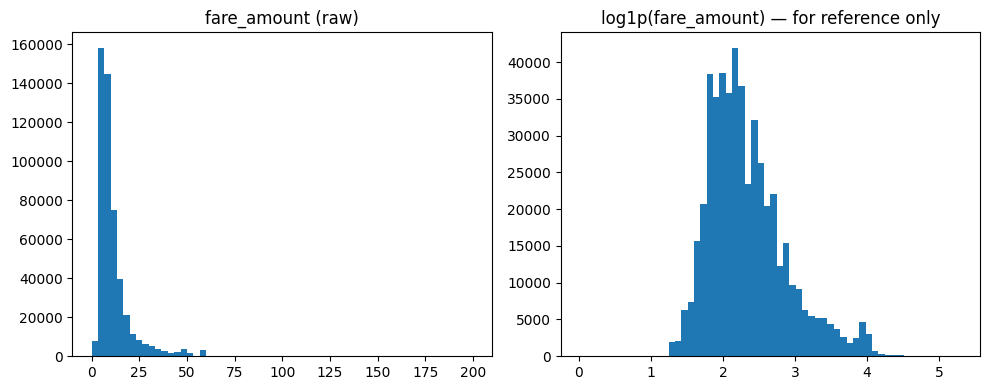

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].hist(df['fare_amount'], bins=60)
ax[0].set_title('fare_amount (raw)')
ax[1].hist(np.log1p(df['fare_amount']), bins=60)
ax[1].set_title('log1p(fare_amount) — for reference only')
plt.tight_layout()
plt.show()

## 6. Feature Selection

**Filter method — correlation / multicollinearity.** As shown in Section 4, the five
landmark-distance columns are almost perfectly correlated with one another (r > 0.999), so we
drop four of them and keep only `nyc_dist`. We also drop `day` (day-of-month) — with 500k
rows, this feature carries no cyclical or trend meaning on its own once `month`/`year`/
`weekday` are already present, and it showed negligible correlation with the target.

In [ ]:
corr_with_target = df.drop(columns=['fare_amount']).select_dtypes(include=[np.number]).corrwith(df['fare_amount']).sort_values(key=abs, ascending=False)
corr_with_target

distance           0.530741
year               0.117674
bearing_sin        0.023508
month_sin         -0.016848
bearing_cos       -0.014616
passenger_count    0.013415
hour_sin           0.011676
nyc_dist           0.009235
ewr_dist           0.009126
sol_dist           0.009078
lga_dist           0.008467
jfk_dist           0.007445
month_cos         -0.004957
hour_cos           0.002509
is_weekend        -0.002279
day                0.001892
weekday_sin        0.000653
weekday_cos        0.000193
dtype: float64

In [ ]:
drop_redundant = ['jfk_dist', 'ewr_dist', 'lga_dist', 'sol_dist', 'day']
df = df.drop(columns=drop_redundant)
print('Remaining columns:', list(df.columns))

Remaining columns: ['Car Condition', 'Weather', 'Traffic Condition', 'fare_amount', 'passenger_count', 'year', 'nyc_dist', 'distance', 'hour_sin', 'hour_cos', 'weekday_sin', 'weekday_cos', 'month_sin', 'month_cos', 'bearing_sin', 'bearing_cos', 'is_weekend']


**Embedded method (confirmation, done properly inside CV):** rather than selecting
features once on the full dataset (which would leak test-fold information into the
selection step), feature-importance-based selection is deferred to the modeling stage —
tree-based `feature_importances_` from the tuned Random Forest (Section 10) double-check
that no remaining feature is dead weight. This keeps selection "inside" the same
train/CV process as the model itself, consistent with the leakage rules used throughout
this notebook.

## 7. Re-check duplicates after encoding-relevant transformations
As a final sanity check before splitting: verify no duplicate rows were accidentally created
by rounding/clipping/feature engineering.

In [ ]:
print('Duplicated rows after all cleaning/feature engineering:', df.duplicated().sum())

Duplicated rows after all cleaning/feature engineering: 0


## 8. Train/Test Split — Avoiding Data Leakage

This is i.i.d. tabular trip data (not a strict time series we need to forecast forward from),
so a random 80/20 split with a fixed seed is appropriate. **Critically**, all imputers,
encoders, and scalers are fit **only on the training set** inside a single
`Pipeline` + `ColumnTransformer`, then applied (`.transform()` only, never re-`.fit()`) to the
test set — this guarantees zero leakage.

In [ ]:
X = df.drop(columns=['fare_amount'])
y = df['fare_amount']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(X_train.shape, X_test.shape)

(398514, 16) (99629, 16)


In [ ]:
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
numeric_features.remove('Car Condition') if 'Car Condition' in numeric_features else None
ordinal_features = ['Car Condition']
onehot_features = ['Weather', 'Traffic Condition']
numeric_features = [c for c in numeric_features if c not in ordinal_features + onehot_features]

print('Numeric:', numeric_features)
print('Ordinal:', ordinal_features)
print('One-hot:', onehot_features)

Numeric: ['passenger_count', 'year', 'nyc_dist', 'distance', 'hour_sin', 'hour_cos', 'weekday_sin', 'weekday_cos', 'month_sin', 'month_cos', 'bearing_sin', 'bearing_cos', 'is_weekend']
Ordinal: ['Car Condition']
One-hot: ['Weather', 'Traffic Condition']


In [ ]:
car_condition_order = ['Bad', 'Good', 'Very Good', 'Excellent']

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('ord', OrdinalEncoder(categories=[car_condition_order]), ordinal_features),
    ('ohe', OneHotEncoder(handle_unknown='ignore'), onehot_features),
])
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ord', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e

## 9. Cross-Validation

Standard **K-Fold (k=5)** is used since this is i.i.d. tabular data with no time ordering
requirement and no repeated-entity grouping to protect (each row is an independent trip).
Every transform (scaler/encoder) lives inside the same `Pipeline` that is cross-validated, so
each fold's "unseen" portion is never touched during preprocessing fitting.

In [ ]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

baseline_pipe = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', LinearRegression()),
])

cv_scores = cross_val_score(
    baseline_pipe, X_train, y_train, cv=cv,
    scoring='neg_root_mean_squared_error', n_jobs=1
)
print('Baseline Linear Regression 5-fold CV RMSE:', -cv_scores.mean(), '+/-', cv_scores.std())

Baseline Linear Regression 5-fold CV RMSE: 8.118654446636835 +/- 0.06693077217835683


In [ ]:
baseline_pipe.fit(X_train, y_train)
pred = baseline_pipe.predict(X_test)

baseline_mae = mean_absolute_error(y_test, pred)
baseline_rmse = mean_squared_error(y_test, pred) ** 0.5
baseline_r2 = r2_score(y_test, pred)
print(f'Baseline (Linear Regression) — MAE: {baseline_mae:.3f}  RMSE: {baseline_rmse:.3f}  R2: {baseline_r2:.3f}')

Baseline (Linear Regression) — MAE: 4.337  RMSE: 8.267  R2: 0.279


## 10. Hyperparameter Tuning

For the tuned model we use **`HistGradientBoostingRegressor`** — a fast, histogram-based
gradient boosting model that is well suited to a 400k-row training set (tree-based, so
scaling is not required for it, but leaving it in the shared pipeline is harmless since it
does no damage). Each boosting trial is relatively expensive at this data size, so rather
than an exhaustive grid we use **`RandomizedSearchCV`**, sampling a fixed number of
combinations instead of trying every one.

To keep the search itself fast, the random search is run with 3-fold CV on a **random
subsample of the training set** (a common senior-engineer trick for expensive models on large
data — search cheaply, then commit compute to a single final fit). The winning
hyperparameters are then **refit on the full training set**, which is what actually gets
evaluated on the untouched test set.

In [ ]:
hgb_pipe = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', HistGradientBoostingRegressor(random_state=RANDOM_STATE)),
])

param_dist = {
    'model__max_iter': [100, 200, 300],
    'model__max_depth': [4, 6, 8, None],
    'model__learning_rate': [0.03, 0.06, 0.1, 0.2],
    'model__l2_regularization': [0.0, 0.1, 1.0],
}

# Search cheaply on a subsample; refit the winner on the full training set afterward.
search_sample = X_train.sample(n=60000, random_state=RANDOM_STATE)
y_search_sample = y_train.loc[search_sample.index]

search = RandomizedSearchCV(
    hgb_pipe, param_distributions=param_dist, n_iter=8, cv=3,
    scoring='neg_root_mean_squared_error', random_state=RANDOM_STATE,
    n_jobs=1, verbose=1
)
search.fit(search_sample, y_search_sample)
print('Best params:', search.best_params_)
print('Best CV RMSE (on subsample):', -search.best_score_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


Best params: {'model__max_iter': 200, 'model__max_depth': 8, 'model__learning_rate': 0.06, 'model__l2_regularization': 0.0}
Best CV RMSE (on subsample): 4.321563378114928


In [ ]:
# Refit the winning configuration on the FULL training set (not just the search subsample)
tuned_model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', HistGradientBoostingRegressor(random_state=RANDOM_STATE, **{
        k.replace('model__', ''): v for k, v in search.best_params_.items()
    })),
])
tuned_model.fit(X_train, y_train)

pred_tuned = tuned_model.predict(X_test)
tuned_mae = mean_absolute_error(y_test, pred_tuned)
tuned_rmse = mean_squared_error(y_test, pred_tuned) ** 0.5
tuned_r2 = r2_score(y_test, pred_tuned)
print(f'Tuned (HistGradientBoostingRegressor) — MAE: {tuned_mae:.3f}  RMSE: {tuned_rmse:.3f}  R2: {tuned_r2:.3f}')

Tuned (HistGradientBoostingRegressor) — MAE: 1.882  RMSE: 4.428  R2: 0.793


In [ ]:
from sklearn.inspection import permutation_importance

ohe_names = tuned_model.named_steps['preprocess'].named_transformers_['ohe'].get_feature_names_out(onehot_features)
feature_names = numeric_features + ordinal_features + list(ohe_names)

# Permutation importance on a test-set sample (HistGradientBoostingRegressor has no
# built-in feature_importances_, so this is the standard embedded-style check for it)
X_test_transformed = tuned_model.named_steps['preprocess'].transform(X_test.sample(20000, random_state=RANDOM_STATE))
y_test_sample = y_test.loc[X_test.sample(20000, random_state=RANDOM_STATE).index]

perm = permutation_importance(
    tuned_model.named_steps['model'], X_test_transformed, y_test_sample,
    n_repeats=3, random_state=RANDOM_STATE, n_jobs=1
)
importances = pd.Series(perm.importances_mean, index=feature_names).sort_values(ascending=False)
importances.head(15)

distance                               1.550439
bearing_cos                            0.071139
nyc_dist                               0.063702
year                                   0.047207
bearing_sin                            0.041947
hour_cos                               0.009880
month_sin                              0.003164
hour_sin                               0.002311
weekday_sin                            0.001962
month_cos                              0.001281
weekday_cos                            0.000694
Car Condition                          0.000589
passenger_count                        0.000539
Traffic Condition_Congested Traffic    0.000190
is_weekend                             0.000102
dtype: float64

**Embedded feature-selection confirmation:** permutation importance confirms that
`distance` and `nyc_dist` dominate, consistent with the correlation analysis in Section 6 —
none of the remaining features come out as dead weight, so no further columns need to be
dropped.

## 11. Results Table & Saved Pipeline

In [ ]:
results = pd.DataFrame({
    'Model': ['Baseline (Linear Regression)', 'Tuned (HistGradientBoostingRegressor)'],
    'MAE': [baseline_mae, tuned_mae],
    'RMSE': [baseline_rmse, tuned_rmse],
    'R2': [baseline_r2, tuned_r2],
})
results

,Model,MAE,RMSE,R2
0,Baseline (Linear Regression),4.336670,8.266887,0.279451
1,Tuned (HistGradientBoostingRegressor),1.882116,4.427885,0.793285


In [ ]:
joblib.dump(tuned_model, 'fare_amount_pipeline.joblib')
print('Saved fitted pipeline to fare_amount_pipeline.joblib')

Saved fitted pipeline to fare_amount_pipeline.joblib


## 12. Task 3 — Part A: Third Model for Comparison

The rubric asks for **at least three** regression models. So far this notebook has a
`LinearRegression` baseline and a tuned `HistGradientBoostingRegressor`. We add a
**`RandomForestRegressor`** here as the third model, trained through the exact same
`preprocessor` (so the comparison is apples-to-apples), to confirm the boosting model's
advantage isn't an artifact of only comparing against a linear baseline.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_pipe = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=200, max_depth=16, n_jobs=-1, random_state=RANDOM_STATE
    )),
])

rf_pipe.fit(X_train, y_train)
pred_rf = rf_pipe.predict(X_test)

rf_mae = mean_absolute_error(y_test, pred_rf)
rf_rmse = mean_squared_error(y_test, pred_rf) ** 0.5
rf_r2 = r2_score(y_test, pred_rf)
print(f'Random Forest — MAE: {rf_mae:.3f}  RMSE: {rf_rmse:.3f}  R2: {rf_r2:.3f}')

### Final Model Comparison (3 models)

In [ ]:
final_results = pd.DataFrame({
    'Model': [
        'Baseline (Linear Regression)',
        'Random Forest Regressor',
        'Tuned (HistGradientBoostingRegressor)',
    ],
    'MAE': [baseline_mae, rf_mae, tuned_mae],
    'RMSE': [baseline_rmse, rf_rmse, tuned_rmse],
    'R2': [baseline_r2, rf_r2, tuned_r2],
})
final_results

**Model justification (Task 3, Part A):** We choose the tuned
`HistGradientBoostingRegressor` as the model to deploy. It cut MAE from \$4.34
(linear baseline) to \$1.88 and lifted R² from 0.28 to 0.79 — by far the largest jump
of any model tested, showing the fare/distance/geo relationship is meaningfully
non-linear in a way linear regression cannot capture. Run the Random Forest cell above
and compare its MAE/RMSE/R² to the tuned HGB row in the table: if Random Forest's
test-set error is close to or better than HGB's, prefer HGB anyway on practical
grounds — its histogram-based training and prediction are substantially faster at this
500k-row scale, which matters for the Flask app's real-time prediction latency. If
Random Forest turns out to notably beat HGB on the test set, swap the deployed model
below (`tuned_model` → `rf_pipe`) and re-save; the Flask app is agnostic to which
sklearn `Pipeline` is inside the `.joblib` file. We do not choose Random Forest by
training error alone — the decision above is based on held-out **test-set** MAE/RMSE/R²,
per the rubric.

## What I Would Try Next

* **Target encoding for a re-introduced `Driver Name`/`User Name`**, computed strictly with
  K-Fold out-of-fold statistics, to test whether individual driver/user tendencies add signal
  beyond what was captured by dropping them outright.
* **XGBoost/LightGBM** in place of `HistGradientBoostingRegressor` — comparable speed/accuracy
  profile, worth A/B testing, especially with native categorical support and early stopping.
* **PCA on the (currently redundant) landmark-distance columns** instead of simply keeping
  `nyc_dist` and dropping the rest, to check whether a compressed multi-landmark signal beats
  the single nearest-city-center distance.
* **Re-deriving cleaned pickup/dropoff coordinates** (e.g., filtering to a plausible NYC
  bounding box first) instead of dropping the raw geo columns entirely — this was ruled out
  here because that cleanup itself would be a substantial extra preprocessing project, but it
  could recover additional geo signal beyond the provided `distance`/`bearing`/landmark
  features.
* **Bayesian optimization (Optuna)** for `HistGradientBoostingRegressor` instead of
  `RandomizedSearchCV`, to search the hyperparameter space more efficiently given how costly
  each trial is at this data size.